# EGM vs NEGM: selfgen parameter recovery

Compare how EGM(FUES) and NEGM(FUES) recover the true calibration parameters from selfgen data. Each method solves the model at uniform CE draws, simulates, and matches moments generated from the YAML defaults. The true parameters are known — this is a controlled recovery test.

For each run we report: estimated theta, distance from truth, SE, convergence, and runtime.

In [1]:
import warnings
warnings.filterwarnings('ignore', message='.*IProgress.*')

import json, os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO_ROOT = os.path.abspath('../../..')
sys.path.insert(0, REPO_ROOT)
os.chdir(REPO_ROOT)

# ── Gadi mount ──
GADI = os.path.expanduser('~/gadi/g/data/tp66/results/durables2_0/estimation')

def list_runs(spec_prefix=None):
    """List all available runs, optionally filtered by spec prefix."""
    runs = []
    for spec in sorted(os.listdir(GADI)):
        spec_dir = os.path.join(GADI, spec)
        if not os.path.isdir(spec_dir):
            continue
        if spec_prefix and not spec.startswith(spec_prefix):
            continue
        for item in sorted(os.listdir(spec_dir)):
            p = os.path.join(spec_dir, item)
            if os.path.isfile(os.path.join(p, 'summary.json')):
                runs.append(f'{spec}/{item}')
            elif os.path.isdir(p):
                for sub in sorted(os.listdir(p)):
                    if os.path.isfile(os.path.join(p, sub, 'summary.json')):
                        runs.append(f'{spec}/{item}/{sub}')
    return runs

def load_run(run_path):
    """Load summary.json from a run path (relative to GADI)."""
    full = os.path.join(GADI, run_path, 'summary.json')
    with open(full) as f:
        return json.load(f)

# Show available selfgen runs
print('Available selfgen runs:')
for r in list_runs('selfgen'):
    print(f'  {r}')

Available selfgen runs:
  selfgen_large_egm/est_20260328_001535
  selfgen_large_egm/est_20260328_002907
  selfgen_large_egm/est_20260328_010554
  selfgen_large_egm/est_20260328_011744
  selfgen_large_egm/est_20260328_012600
  selfgen_large_negm/est_20260328_001353
  selfgen_large_negm/est_20260328_010522
  selfgen_large_negm/est_20260328_011746
  selfgen_large_negm/est_20260328_012600
  selfgen_sweep_gamma_c_egm/gamma_c=1.5/est_20260328_002905
  selfgen_sweep_gamma_c_egm/gamma_c=1.5/est_20260328_010523
  selfgen_sweep_gamma_c_egm/gamma_c=1.5/est_20260328_013246
  selfgen_sweep_gamma_c_egm/gamma_c=1.83/est_20260328_002903
  selfgen_sweep_gamma_c_egm/gamma_c=1.83/est_20260328_010520
  selfgen_sweep_gamma_c_egm/gamma_c=1.83/est_20260328_013243
  selfgen_sweep_gamma_c_egm/gamma_c=2.17/est_20260328_002908
  selfgen_sweep_gamma_c_egm/gamma_c=2.17/est_20260328_010524
  selfgen_sweep_gamma_c_egm/gamma_c=2.17/est_20260328_013246
  selfgen_sweep_gamma_c_egm/gamma_c=2.5/est_20260328_002904
  self

## 1. Select runs

Pick one EGM and one NEGM selfgen run to compare. Use the latest converged run for each method.

In [2]:
# ── Select runs to compare ──
# Change these paths to point at different runs.
RUNS = {
    'EGM':  'selfgen_large_egm/est_20260328_012600',
    'NEGM': 'selfgen_large_negm/est_20260328_012600',
}

# True parameters (YAML calibration defaults for separable model)
THETA_TRUE = {
    'beta':    0.945,
    'alpha':   0.7,
    'gamma_c': 3.5,
    'gamma_h': 1.5,
    'tau':     0.12,
}

# Load
results = {}
for label, path in RUNS.items():
    results[label] = load_run(path)
    s = results[label]
    print(f'{label}: loss={s["objective"]:.2e}, converged={s["converged"]}, '
          f'n_iter={s["n_iter"]}')

EGM: loss=6.31e-07, converged=True, n_iter=13
NEGM: loss=3.43e-04, converged=True, n_iter=16


## 2. Parameter recovery table

In [3]:
params = sorted(THETA_TRUE.keys())

rows = []
for p in params:
    row = {'Parameter': p, 'True': THETA_TRUE[p]}
    for label in RUNS:
        s = results[label]
        est = s['theta_best'][p]
        se = s['theta_se'].get(p, float('nan'))
        err = est - THETA_TRUE[p]
        row[f'{label} est'] = est
        row[f'{label} SE'] = se
        row[f'{label} err'] = err
    rows.append(row)

# Add summary row
row_loss = {'Parameter': 'Loss'}
row_iter = {'Parameter': 'Iterations'}
row_conv = {'Parameter': 'Converged'}
for label in RUNS:
    s = results[label]
    row_loss[f'{label} est'] = s['objective']
    row_iter[f'{label} est'] = s['n_iter']
    row_conv[f'{label} est'] = s['converged']
    for col in [f'{label} SE', f'{label} err', 'True']:
        row_loss[col] = ''
        row_iter[col] = ''
        row_conv[col] = ''

df = pd.DataFrame(rows + [row_loss, row_iter, row_conv])

# Display
from IPython.display import Markdown

def _fmt(v):
    if isinstance(v, bool):
        return str(v)
    if isinstance(v, float):
        if abs(v) < 1e-3 and v != 0:
            return f'{v:.2e}'
        return f'{v:.6f}'
    if isinstance(v, int):
        return str(v)
    return str(v)

header = '| Parameter | True |'
sep = '|---|---|'
for label in RUNS:
    header += f' {label} est | {label} SE | {label} err |'
    sep += '---|---|---|'

lines = [header, sep]
for _, r in df.iterrows():
    line = f'| {r["Parameter"]} | {_fmt(r["True"])} |'
    for label in RUNS:
        line += f' {_fmt(r[f"{label} est"])} | {_fmt(r[f"{label} SE"])} | {_fmt(r[f"{label} err"])} |'
    lines.append(line)

Markdown('\n'.join(lines))

| Parameter | True | EGM est | EGM SE | EGM err | NEGM est | NEGM SE | NEGM err |
|---|---|---|---|---|---|---|---|
| alpha | 0.700000 | 0.699950 | 1.73e-05 | -5.00e-05 | 0.701126 | 6.23e-06 | 0.001126 |
| beta | 0.945000 | 0.944997 | 2.04e-06 | -2.61e-06 | 0.944862 | 1.29e-06 | -1.38e-04 |
| gamma_c | 3.500000 | 3.500075 | 8.51e-05 | 7.49e-05 | 3.504594 | 1.08e-04 | 0.004594 |
| gamma_h | 1.500000 | 1.499906 | 4.41e-05 | -9.37e-05 | 1.504505 | 3.45e-05 | 0.004505 |
| tau | 0.120000 | 0.120006 | 5.08e-06 | 6.33e-06 | 0.120593 | 1.58e-06 | 5.93e-04 |
| Loss |  | 6.31e-07 |  |  | 3.43e-04 |  |  |
| Iterations |  | 13 |  |  | 16 |  |  |
| Converged |  | True |  |  | True |  |  |

## 3. Recovery accuracy: bar chart

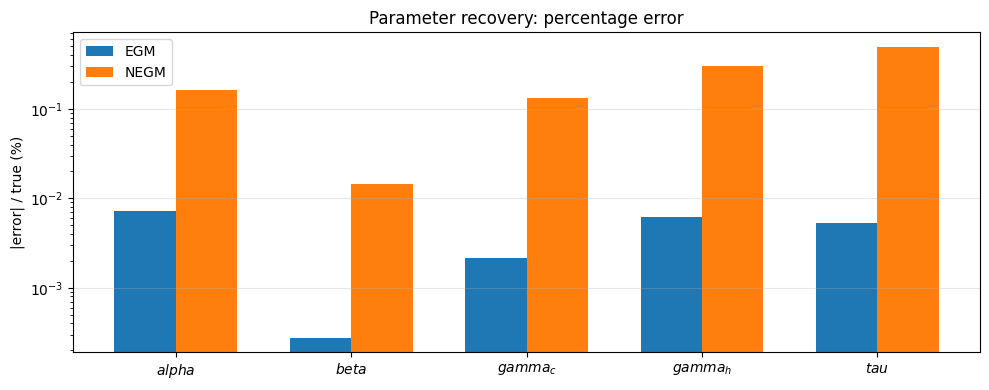

In [4]:
# Percentage error |theta_best - theta_true| / theta_true
labels_method = list(RUNS.keys())
x = np.arange(len(params))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 4))
for i, label in enumerate(labels_method):
    s = results[label]
    pct_err = [100 * abs(s['theta_best'][p] - THETA_TRUE[p]) / THETA_TRUE[p]
               for p in params]
    ax.bar(x + i * width, pct_err, width, label=label)

ax.set_ylabel('|error| / true (%)')
ax.set_title('Parameter recovery: percentage error')
ax.set_xticks(x + width / 2)
ax.set_xticklabels([f'${p}$' for p in params])
ax.legend()
ax.set_yscale('log')
ax.grid(True, axis='y', alpha=0.3)
fig.tight_layout()
plt.show()

## 4. Convergence comparison

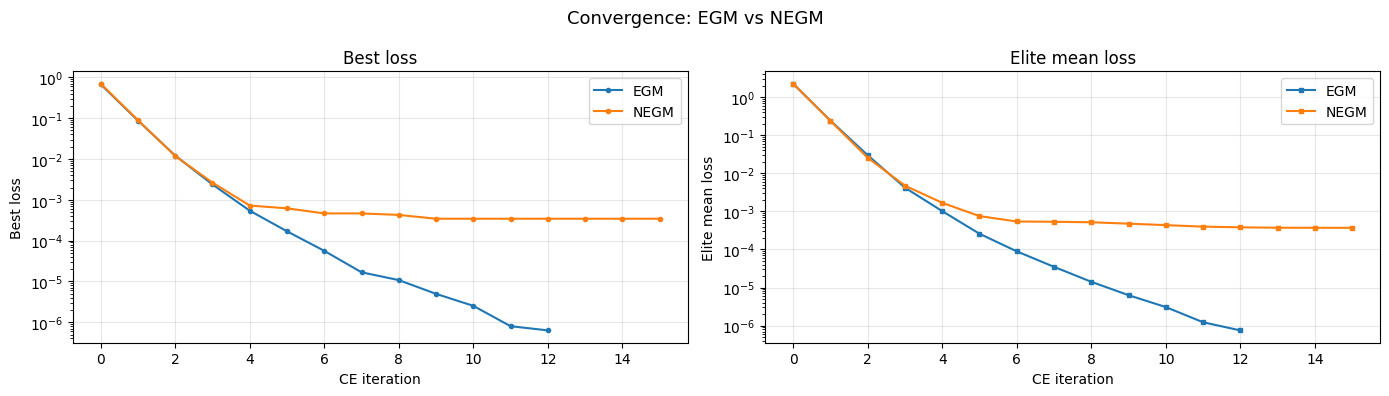

In [5]:
# Load convergence CSVs and plot side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for i, (label, path) in enumerate(RUNS.items()):
    conv_path = os.path.join(GADI, path, 'convergence.csv')
    if not os.path.exists(conv_path):
        print(f'{label}: no convergence.csv')
        continue
    conv = pd.read_csv(conv_path)

    ax = axes[0]
    ax.plot(conv['iter'], conv['best_loss'], 'o-', label=label, markersize=3)

    ax = axes[1]
    ax.plot(conv['iter'], conv['elite_mean_loss'], 's-', label=label, markersize=3)

axes[0].set_xlabel('CE iteration')
axes[0].set_ylabel('Best loss')
axes[0].set_yscale('log')
axes[0].legend()
axes[0].set_title('Best loss')
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('CE iteration')
axes[1].set_ylabel('Elite mean loss')
axes[1].set_yscale('log')
axes[1].legend()
axes[1].set_title('Elite mean loss')
axes[1].grid(True, alpha=0.3)

fig.suptitle('Convergence: EGM vs NEGM', fontsize=13)
fig.tight_layout()
plt.show()

## 5. Gamma_c sweep: recovery across males and females

Each sweep fixes the true gamma_c for selfgen data generation, then estimates all 5 params (including gamma_c). Compares EGM vs NEGM recovery for both genders.

In [ ]:
# ── Load gamma_c sweep results for both genders ──
# Each spec dir may have multiple sweep summaries — use the latest.

SWEEP_SPECS = {
    'EGM females':  'selfgen_sweep_gamma_c_egm',
    'NEGM females': 'selfgen_sweep_gamma_c_negm',
    'EGM males':    'selfgen_sweep_gamma_c_egm',   # same spec name, different mod
    'NEGM males':   'selfgen_sweep_gamma_c_negm',
}

# True values for the 5 free params
SWEEP_TRUE = {
    'beta': 0.945, 'alpha': 0.7, 'gamma_c': None,  # varies per sweep point
    'gamma_h': 1.5, 'tau': 0.12,
}

def _load_sweep_summary(spec_name):
    """Load the latest sweep_summary CSV for a spec."""
    spec_dir = os.path.join(GADI, spec_name)
    if not os.path.isdir(spec_dir):
        return None
    csvs = sorted([f for f in os.listdir(spec_dir) if f.startswith('sweep_summary')])
    if not csvs:
        return None
    return pd.read_csv(os.path.join(spec_dir, csvs[-1]))

def _load_sweep_points(spec_name):
    """Load individual sweep point summaries (fallback if no sweep_summary)."""
    out = {}
    spec_dir = os.path.join(GADI, spec_name)
    if not os.path.isdir(spec_dir):
        return out
    for point_dir in sorted(os.listdir(spec_dir)):
        point_path = os.path.join(spec_dir, point_dir)
        if not os.path.isdir(point_path):
            continue
        run_dirs = sorted([d for d in os.listdir(point_path)
                           if os.path.isfile(os.path.join(point_path, d, 'summary.json'))])
        if not run_dirs:
            continue
        with open(os.path.join(point_path, run_dirs[-1], 'summary.json')) as f:
            s = json.load(f)
        if '=' in point_dir:
            val = float(point_dir.split('=')[1])
            out[val] = s
    return out

# Load all four sweep variants
sweeps = {}
for label, spec in SWEEP_SPECS.items():
    df = _load_sweep_summary(spec)
    if df is not None and len(df) > 0:
        sweeps[label] = df
        print(f'{label}: {len(df)} points from sweep_summary')
    else:
        pts = _load_sweep_points(spec)
        if pts:
            rows = []
            for gc, s in sorted(pts.items()):
                row = {'gamma_c': gc, **s['theta_best'],
                       'objective': s['objective'], 'converged': s['converged'],
                       'n_iter': s['n_iter']}
                rows.append(row)
            sweeps[label] = pd.DataFrame(rows)
            print(f'{label}: {len(rows)} points from individual summaries')
        else:
            print(f'{label}: no data')

# ── Plot: parameter recovery across gamma_c ──
free_params = ['alpha', 'beta', 'gamma_c', 'gamma_h', 'tau']
true_vals = {'alpha': 0.7, 'beta': 0.945, 'gamma_h': 1.5, 'tau': 0.12}

styles = {
    'EGM females':  dict(color='blue', linestyle='-', marker='o', markersize=4),
    'NEGM females': dict(color='red', linestyle='--', marker='s', markersize=4),
    'EGM males':    dict(color='blue', linestyle='-', marker='^', markersize=5, alpha=0.5),
    'NEGM males':   dict(color='red', linestyle='--', marker='v', markersize=5, alpha=0.5),
}

if sweeps:
    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    axes = axes.ravel()

    for i, p in enumerate(free_params):
        ax = axes[i]
        if p == 'gamma_c':
            # For gamma_c: plot estimated vs true (45-degree line)
            ax.plot([1, 9], [1, 9], 'k:', linewidth=1, label='True (45-deg)')
        elif p in true_vals:
            ax.axhline(true_vals[p], color='k', linestyle=':', linewidth=1, label='True')

        for label, df in sweeps.items():
            if 'gamma_c' in df.columns and p in df.columns:
                ax.plot(df['gamma_c'], df[p], label=label, linewidth=2, **styles[label])

        ax.set_xlabel(r'True $\gamma_c$')
        ax.set_ylabel(f'Estimated ${p}$')
        ax.set_title(f'${p}$')
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)

    # Loss comparison
    ax = axes[5]
    for label, df in sweeps.items():
        if 'gamma_c' in df.columns and 'objective' in df.columns:
            ax.plot(df['gamma_c'], df['objective'], label=label, linewidth=2, **styles[label])
    ax.set_xlabel(r'True $\gamma_c$')
    ax.set_ylabel('SMM loss')
    ax.set_yscale('log')
    ax.set_title('Loss')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

    fig.suptitle(r'Parameter recovery across true $\gamma_c$: EGM vs NEGM, males vs females', fontsize=13)
    fig.tight_layout()
    plt.show()
else:
    print('No sweep data available.')

## 6. All selfgen runs summary

Load all available selfgen runs and tabulate for quick comparison.

In [7]:
# Load all selfgen runs
all_runs = list_runs('selfgen')
rows = []
for path in all_runs:
    try:
        s = load_run(path)
    except Exception:
        continue
    # Determine method from spec name
    method = 'NEGM' if 'negm' in path.lower() else 'EGM'
    # Determine if sweep and which param
    sweep_param = ''
    if 'sweep_gamma_c' in path:
        parts = path.split('/')
        for p in parts:
            if p.startswith('gamma_c='):
                sweep_param = p
    elif 'sweep_sigma_w' in path:
        parts = path.split('/')
        for p in parts:
            if p.startswith('sigma_w='):
                sweep_param = p

    row = {
        'run': path.split('/')[-1],  # est_YYYYMMDD_HHMMSS
        'spec': path.split('/')[0],
        'method': method,
        'sweep': sweep_param,
        'loss': s['objective'],
        'converged': s['converged'],
        'n_iter': s['n_iter'],
    }
    for p in sorted(THETA_TRUE.keys()):
        if p in s['theta_best']:
            row[p] = s['theta_best'][p]
    rows.append(row)

all_df = pd.DataFrame(rows)
# Sort by spec then run
all_df = all_df.sort_values(['spec', 'sweep', 'run'])

# Filter to converged runs with non-trivial loss
valid = all_df[(all_df['converged'] == True) & (all_df['loss'] > 1e-20)]
print(f'{len(valid)} converged runs with non-trivial loss (out of {len(all_df)} total)')
print()

cols = ['spec', 'method', 'sweep', 'loss', 'n_iter'] + sorted(THETA_TRUE.keys())
print(valid[cols].to_string(index=False, float_format='%.6f'))

70 converged runs with non-trivial loss (out of 107 total)

                      spec method        sweep     loss  n_iter    alpha     beta  gamma_c  gamma_h      tau
         selfgen_large_egm    EGM              0.000000      11 0.699915 0.944993 3.500224 1.499899 0.120015
         selfgen_large_egm    EGM              0.000000      11 0.699915 0.944993 3.500224 1.499899 0.120015
         selfgen_large_egm    EGM              0.000000      11 0.699915 0.944993 3.500224 1.499899 0.120015
         selfgen_large_egm    EGM              0.000001      13 0.699950 0.944997 3.500075 1.499906 0.120006
        selfgen_large_negm   NEGM              0.000257      18 0.699926 0.944876 3.487526 1.498329 0.120585
        selfgen_large_negm   NEGM              0.000257      18 0.699926 0.944876 3.487526 1.498329 0.120585
        selfgen_large_negm   NEGM              0.000343      16 0.701126 0.944862 3.504594 1.504505 0.120593
 selfgen_sweep_gamma_c_egm    EGM  gamma_c=1.5 0.016266      22 0.68

---

*Source: `examples/durables2_0/` — Dobrescu and Shanker (2026), Application 2*